In [ ]:
pip install pandas

In [ ]:
pip install numpy

In [ ]:
import seaborn as sns

In [ ]:
%pip install seaborn

In [ ]:
import seaborn as sns
print("Seaborn installed successfully")

%pip install matplotlib

In [ ]:
# Pandas is most commonly used for data wrangling and data manipulation purposes
# NumPy is a fundamental library for numerical computing in Python.Mathematical Operations, Arrays,Linear Algebra etc
#Removing Duplicates
#Fixing NULL values(Age, Department)
#Standardization of each value(Gender)
#Concatenate First Name and Last Name
#Add a new column(YearsAtCompany)
#STrength by Maritial Status

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
pd.reset_option('display.max_rows')
df = pd.read_csv('/Users/gautamgahlawat/Downloads/project -3/dataset.csv')
#df=df.shape[0]
#print('No of rows:', df)
#df=df.shape[1]
#print('No of columns:', df)

#df=df[df.duplicated()].shape[0]
df=df.drop_duplicates()
#df.info()
#df=df[df['Department'].isnull()]
#df
#df=df[df['Age'].isnull()]
#df
Average_Age=df['Age'].mean()

df['Age'] = df['Age'].fillna(Average_Age)
df['Department'] = df['Department'].fillna('Data Engineering')
#df=df[df['Department']=='Data Engineering'].shape[0]

df['Gender']=df['Gender'].replace({'M':'Male', 'F':'Female'})
df['Full Name'] = df['First Name'] + ' ' + df['Last Name']

columns = df.columns.tolist()
last_name_index = columns.index('Last Name')
last_name_index
columns.insert(last_name_index + 1, columns.pop(columns.index('Full Name')))
df = df[columns]

#Get the number of experience 

hire_date = pd.to_datetime(df['Hire_Date']).dt.year
#hire_date
current_year = datetime.now().year
#current_year
df['Years_At_Company'] = current_year - hire_date

# Step 1: bulk rename
df.columns = df.columns.str.lower().str.replace(' ', '_')

df.rename(columns={'maritalstatus': 'marital_status'}, inplace=True)

df.drop(columns=['yearsatcompany'], inplace=True)

df.rename(columns={'trainingtimeslastyear': 'training_time_lastyear'}, inplace=True)
df.rename(columns={'worklifebalance': 'worklife_balance'}, inplace=True)
df.rename(columns={'monthlyrate': 'monthly_rate'}, inplace=True)


df['age'] = df['age'].astype(int)
df


,employee_id,first_name,last_name,full_name,gender,marital_status,department,grade,employee_count,job_satisfaction,...,monthly_rate,age,job_type,job_experience,hire_date,company_environment,training_time_lastyear,worklife_balance,country,years_at_company
0,1,Shelia,Mahoney,Shelia Mahoney,Male,Single,Sales,2,1,4,...,19479,41,Permannent,16,1/1/2010,5,0,1,United Kingdom,16
1,2,Jo,Rivers,Jo Rivers,Female,Married,TECH,2,1,2,...,24907,49,Contractual,14,2/1/2012,3,3,3,United States,14
2,3,Sheryl,Lowery,Sheryl Lowery,Female,Single,TECH,1,1,3,...,2396,37,Contractual,14,2/2/2012,4,3,3,Australia,14
3,4,Whitney,Hooper,Whitney Hooper,Male,Married,TECH,1,1,3,...,23159,33,Contractual,14,2/3/2012,4,3,3,Australia,14
4,5,Lindsey,Rice,Lindsey Rice,Female,Married,Manfacturing,1,1,2,...,16632,27,Contractual,14,2/4/2012,1,3,3,Australia,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1497,1466,Shelley,Benjamin,Shelley Benjamin,Male,Married,Data Engineering,2,1,4,...,12290,36,Contractual,8,2/1/2019,3,3,3,France,7
1498,1467,Isaiah,Jarvis,Isaiah Jarvis,Male,Married,Data Engineering,3,1,5,...,21457,39,Contractual,8,2/2/2019,5,5,3,France,7
1499,1468,Nathan,Sutton,Nathan Sutton,Female,Married,Data Engineering,2,1,2,...,5174,27,Contractual,8,2/3/2019,2,0,3,France,7
1500,1469,Earl,Mccullough,Earl Mccullough,Female,Married,Sales,2,1,2,...,13243,49,Contractual,8,2/4/2019,4,3,2,France,7


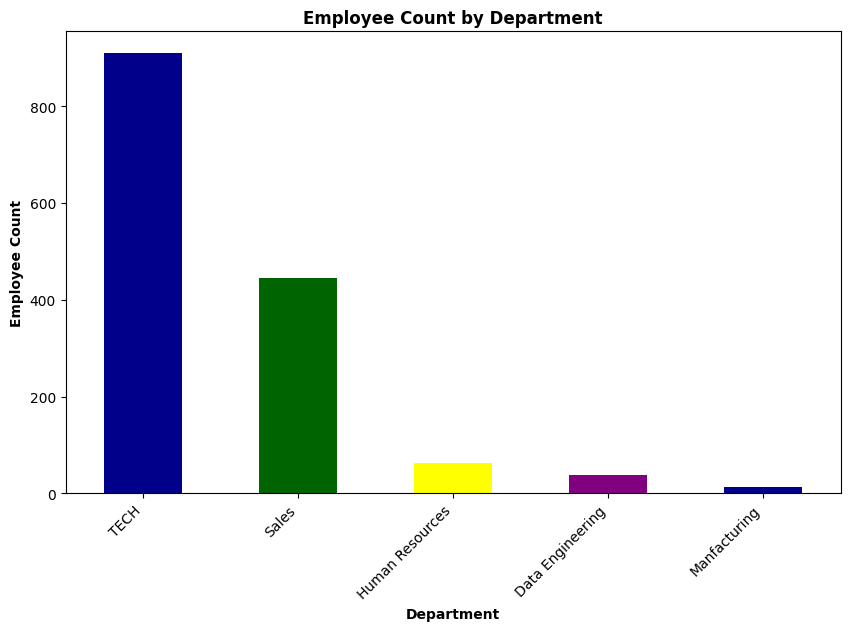

In [101]:
# Bar Chart
color=['darkblue','darkgreen','yellow','purple']

department_count=df['department'].value_counts()
plt.figure(figsize=(10,6))

department_count.plot(kind='bar', color=color)

plt.title('Employee Count by Department', fontweight='bold')
plt.xlabel('Department', fontweight='bold')
plt.ylabel('Employee Count', fontweight='bold')

plt.xticks(rotation=45, ha='right')

plt.show()



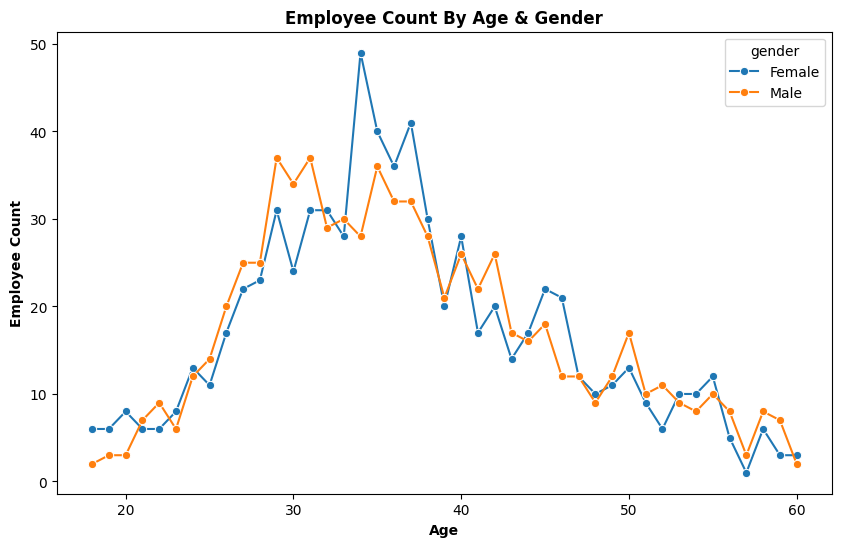

In [102]:
# Line Chart
age_gender=df.groupby(['age', 'gender']).size().reset_index(name='count')
age_gender
plt.figure(figsize=(10,6))
sns.lineplot(data=age_gender, x='age', y='count', hue='gender', marker='o')
plt.title('Employee Count By Age & Gender', fontweight='bold')
plt.xlabel('Age', fontweight='bold')
plt.ylabel('Employee Count', fontweight='bold')
plt.xticks(rotation=0)
plt.show() 

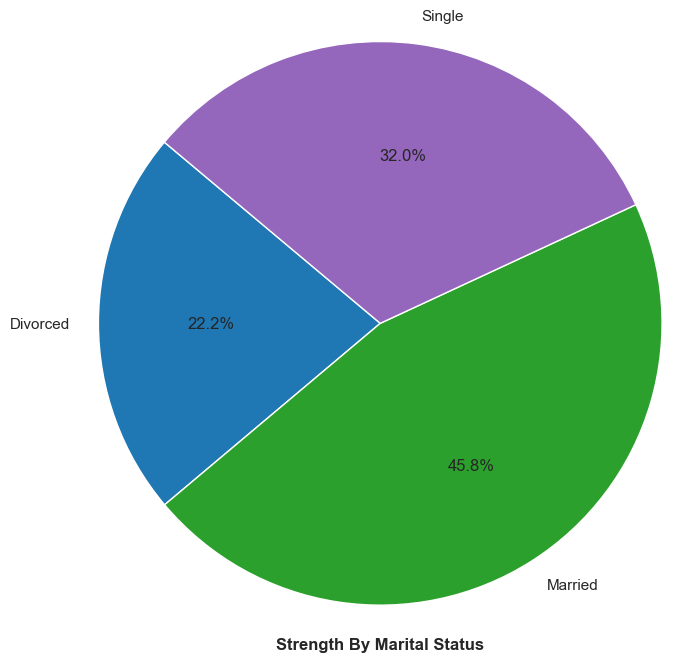

In [105]:
# Pie chart
marital_status_count=df.groupby(['marital_status']).size().reset_index(name='count')
marital_status=marital_status_count['marital_status']
count=marital_status_count['count']

sns.set(style="whitegrid")
color=sns.color_palette("colorblind")[0:len(marital_status)]
colors=['#1f77b4', '#2ca02c', '#9467bd']
plt.figure(figsize=(8,8))
plt.pie(count, labels=marital_status, colors=colors, autopct='%1.1f%%', startangle=140)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle

plt.xlabel('Strength By Marital Status', fontweight='bold')
plt.show() 


<function matplotlib.pyplot.show(close=None, block=None)>

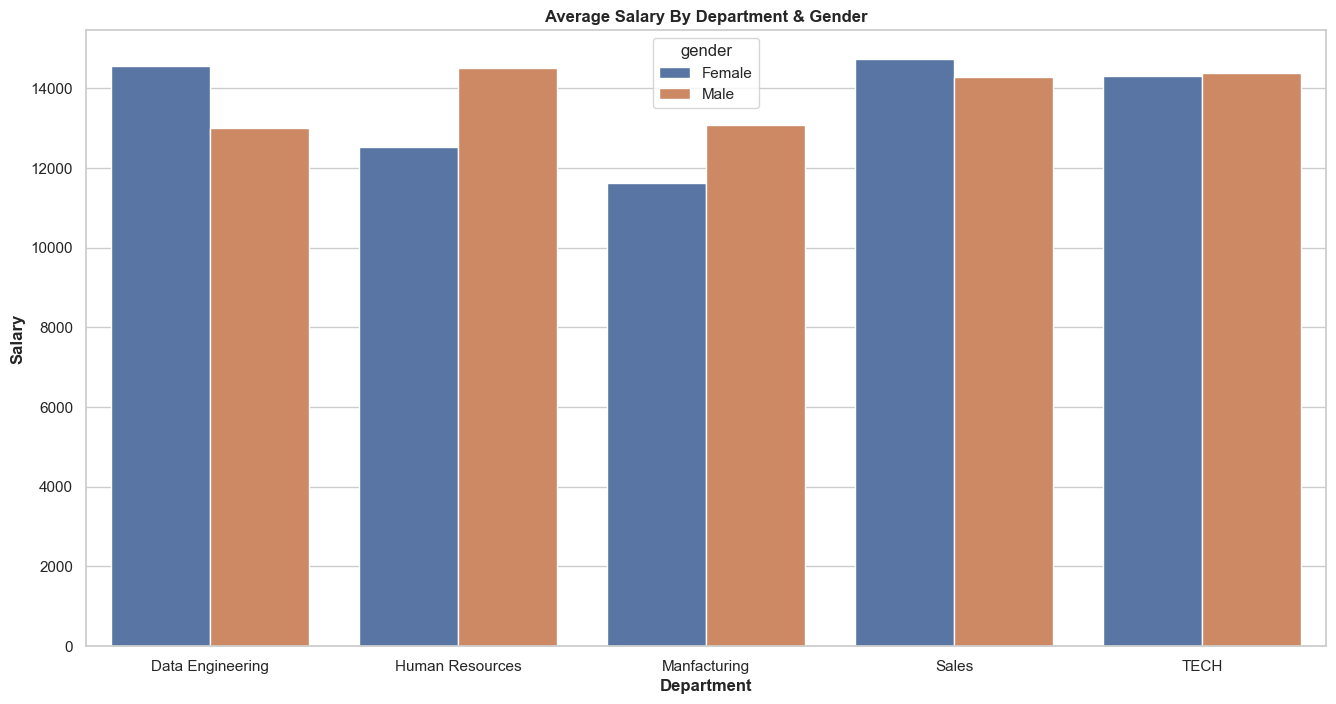

In [112]:
# Bar PLot
df=df.rename(columns={'monthly_rate': 'salary'})
average_salary = df.groupby(['department', 'gender'])['salary'].mean().reset_index()
plt.figure(figsize=(16, 8))
sns.barplot(data=average_salary, x='department', y='salary', hue='gender')
plt.title('Average Salary By Department & Gender', fontweight = 'bold')
plt.xlabel('Department', fontweight='bold')
plt.ylabel('Salary', fontweight='bold')
plt.show



<function matplotlib.pyplot.show(close=None, block=None)>

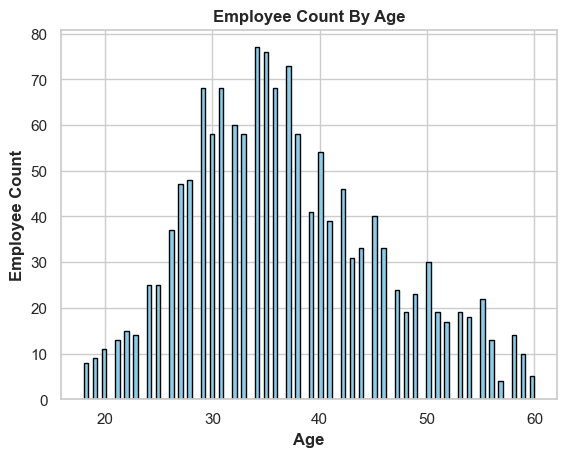

In [114]:
# Histogram
age=df['age']
plt.hist(age, bins=100, edgecolor='black', color='skyblue')
plt.title('Employee Count By Age', fontweight = 'bold')
plt.xlabel('Age', fontweight='bold')
plt.ylabel('Employee Count', fontweight='bold')
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

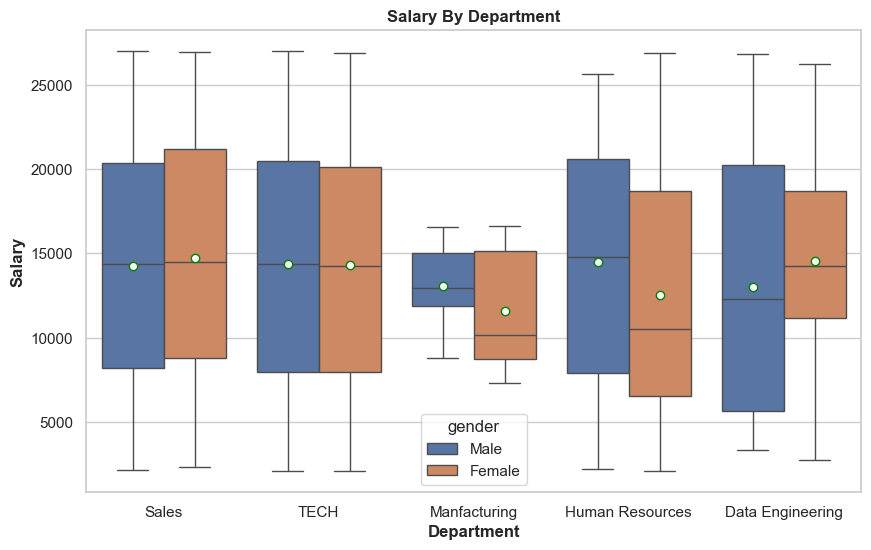

In [117]:
# Box Plot

plt.figure(figsize=(10, 6))
sns.boxplot(x='department', y='salary', data=df, hue='gender', showmeans='True', meanprops={"marker":"o"
                                                                                            ,"markerfacecolor":"white"
                                                                                            ,"markersize":"6"
                                                                                            ,"markeredgecolor":"green"})
plt.title('Salary By Department', fontweight = 'bold')
plt.xlabel('Department', fontweight='bold')
plt.ylabel('Salary', fontweight='bold')
plt.show